# Project 07: Multi-Agent AI Platform

Proposed-only implementation: **Agent Graph Router + RAG Transformer + Verifier**.

Task: multi-label prediction of 14 MAST failure modes from multi-agent execution traces. The MAD dataset has failure annotations, not optimal-routing labels; `routing_scores` below are failure-risk scores, not supervised claims about the best agent route.

## 0. Setup

In [1]:
!pip -q install huggingface_hub sentence-transformers scikit-learn tqdm

import json, os, random, hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from huggingface_hub import hf_hub_download
from sentence_transformers import SentenceTransformer
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import f1_score, hamming_loss, accuracy_score
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
assert torch.cuda.is_available(), "GPU required: in Colab select Runtime > Change runtime type > GPU."
DEVICE = torch.device("cuda:0")
print("Device:", DEVICE)

Device: cuda:0


In [2]:
CONFIG = {
    "repo_id": "mcemri/MAST-Data",
    "filename": "MAD_full_dataset.json",
    "embedding_model": "sentence-transformers/all-MiniLM-L6-v2",
    "max_traces": 1642,
    "retrieval_k": 5,
    "batch_size": 64,
    "epochs": 20,
    "patience": 5,
    "learning_rate": 1e-3,
    "results_dir": "data/07/results",
    "figures_dir": "data/07/figures",
}
for key in ("results_dir", "figures_dir"):
    os.makedirs(CONFIG[key], exist_ok=True)
CONFIG

{'repo_id': 'mcemri/MAST-Data',
 'filename': 'MAD_full_dataset.json',
 'embedding_model': 'sentence-transformers/all-MiniLM-L6-v2',
 'max_traces': 1642,
 'retrieval_k': 5,
 'batch_size': 64,
 'epochs': 20,
 'patience': 5,
 'learning_rate': 0.001,
 'results_dir': 'data/07/results',
 'figures_dir': 'data/07/figures'}

## 1. Dataset acquisition and schema validation

In [3]:
dataset_path = hf_hub_download(
    repo_id=CONFIG["repo_id"], filename=CONFIG["filename"], repo_type="dataset"
)
records = json.loads(Path(dataset_path).read_text(encoding="utf-8"))
if isinstance(records, dict):
    records = records.get("data", records.get("records", list(records.values())))
records = records[:CONFIG["max_traces"]]

# Real HF datasets vary in field naming; detect the annotation/trace keys defensively
# instead of hardcoding "mast_annotation"/"trace" (which don't always match upstream schema).
ANNOTATION_KEY_CANDIDATES = ["mast_annotation", "annotation", "annotations", "label", "labels", "failure_mode", "failure_modes"]
TRACE_KEY_CANDIDATES = ["trace", "traces", "conversation", "messages", "trajectory"]

available_fields = sorted(records[0].keys()) if records else []
print("Available fields in first record:", available_fields)

def _pick_key(candidates, fields):
    for c in candidates:
        if c in fields:
            return c
    return None

ANNOTATION_KEY = _pick_key(ANNOTATION_KEY_CANDIDATES, available_fields)
TRACE_KEY = _pick_key(TRACE_KEY_CANDIDATES, available_fields)

assert records and ANNOTATION_KEY is not None and TRACE_KEY is not None, (
    f"Could not find annotation/trace fields. Available columns: {available_fields}. "
    f"Tried annotation candidates {ANNOTATION_KEY_CANDIDATES} and trace candidates {TRACE_KEY_CANDIDATES}."
)
print(f"Using annotation key '{ANNOTATION_KEY}' and trace key '{TRACE_KEY}'")
print("Records:", len(records)); print("Fields:", available_fields)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


MAD_full_dataset.json: reconstructing file:   0%|          |  0.00B /  200MB            

MAD_full_dataset.json: downloading bytes:           |  0.00B            

Available fields in first record: ['benchmark_name', 'llm_name', 'mas_name', 'mast_annotation', 'trace', 'trace_id']
Using annotation key 'mast_annotation' and trace key 'trace'
Records: 1642
Fields: ['benchmark_name', 'llm_name', 'mas_name', 'mast_annotation', 'trace', 'trace_id']


In [4]:
def flatten_trace(value):
    if isinstance(value, dict):
        if "trajectory" in value:
            return flatten_trace(value["trajectory"])
        return " ".join(f"{k}: {flatten_trace(v)}" for k, v in value.items())
    if isinstance(value, list):
        return " ".join(flatten_trace(v) for v in value)
    return str(value)

label_codes = sorted({str(k) for row in records for k in row[ANNOTATION_KEY].keys()})
assert len(label_codes) == 14, f"Expected 14 MAST modes, found {label_codes}"

rows = []
for i, row in enumerate(records):
    annotation = row[ANNOTATION_KEY]
    labels = [float(annotation.get(code) or 0) for code in label_codes]
    trace_text = flatten_trace(row[TRACE_KEY])
    rows.append({
        "trace_id": f"{row.get('mas_name','unknown')}::{i}",
        "mas_name": str(row.get("mas_name", "unknown")),
        "benchmark_name": str(row.get("benchmark_name", "unknown")),
        "text": trace_text[:12000],
        "labels": np.asarray(labels, dtype=np.float32),
    })
df = pd.DataFrame(rows)
assert df.trace_id.is_unique, "trace_id construction produced duplicates - check the enumerate-based ID logic."
print(df[["mas_name", "benchmark_name"]].nunique())
print("Failure prevalence:", np.stack(df.labels).mean(0).round(3).tolist())
# Target sanity check: MAST is multi-label (14 codes) - verify at least 2 labels actually vary,
# so a row-limiting/sorting bug upstream can't silently collapse a label to one class.
label_matrix = np.stack(df.labels)
per_label_pos = label_matrix.sum(0)
varying_labels = int(((per_label_pos > 0) & (per_label_pos < len(label_matrix))).sum())
assert varying_labels >= 2, f"DEGENERATE TARGET: only {varying_labels} of {len(label_codes)} label columns have both 0 and 1 present - {dict(zip(label_codes, per_label_pos.tolist()))}. Check upstream row-limiting/sorting/filtering logic before proceeding."
minority_frac = np.minimum(per_label_pos, len(label_matrix) - per_label_pos) / len(label_matrix)
rare_labels = [c for c, frac in zip(label_codes, minority_frac) if frac < 0.01]
if rare_labels or len(label_matrix) < 100:
    print(f"[DATA QUALITY WARNING] rows={len(label_matrix)}; labels with <1% minority prevalence: {rare_labels}")


mas_name          7
benchmark_name    8
dtype: int64
Failure prevalence: [0.36000001430511475, 0.054999999701976776, 0.40400001406669617, 0.07100000232458115, 0.26600000262260437, 0.04899999871850014, 0.16099999845027924, 0.2150000035762787, 0.014999999664723873, 0.22499999403953552, 0.3709999918937683, 0.16699999570846558, 0.3700000047683716, 0.4009999930858612]


## 2. Leakage-safe deterministic split

In [5]:
def bucket(key):
    return int(hashlib.sha256((str(key) + str(SEED)).encode()).hexdigest()[:8], 16) % 100

split_code = df.trace_id.map(bucket)
train_idx = np.flatnonzero(split_code < 70)
val_idx = np.flatnonzero((split_code >= 70) & (split_code < 85))
test_idx = np.flatnonzero(split_code >= 85)
assert set(df.iloc[train_idx].trace_id).isdisjoint(df.iloc[val_idx].trace_id)
assert set(df.iloc[train_idx].trace_id).isdisjoint(df.iloc[test_idx].trace_id)
assert min(map(len, (train_idx, val_idx, test_idx))) > 0
print("Train/val/test:", len(train_idx), len(val_idx), len(test_idx))

Train/val/test: 1145 249 248


## 3. RAG Transformer embeddings and retrieval

In [6]:
encoder = SentenceTransformer(CONFIG["embedding_model"], device=str(DEVICE))
embeddings = encoder.encode(df.text.tolist(), batch_size=32, show_progress_bar=True, normalize_embeddings=True)
embeddings = np.asarray(embeddings, dtype=np.float32)
Y = np.stack(df.labels.to_numpy()).astype(np.float32)

retriever = NearestNeighbors(n_neighbors=CONFIG["retrieval_k"] + 1, metric="cosine").fit(embeddings[train_idx])
def retrieval_prior(indices, exclude_self=False):
    _, neighbors = retriever.kneighbors(embeddings[indices])
    neighbors = neighbors[:, 1:] if exclude_self else neighbors[:, :CONFIG["retrieval_k"]]
    return Y[train_idx][neighbors].mean(1).astype(np.float32)

retrieval = np.zeros_like(Y)
retrieval[train_idx] = retrieval_prior(train_idx, exclude_self=True)
retrieval[val_idx] = retrieval_prior(val_idx)
retrieval[test_idx] = retrieval_prior(test_idx)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/52 [00:00<?, ?it/s]

## 4. Agent graph construction

In [7]:
agent_names = sorted(df.mas_name.unique())
agent_to_id = {name: i for i, name in enumerate(agent_names)}
agent_ids = df.mas_name.map(agent_to_id).to_numpy(np.int64)

agent_profiles = np.stack([
    Y[train_idx][df.mas_name.iloc[train_idx].to_numpy() == name].mean(0)
    if np.any(df.mas_name.iloc[train_idx].to_numpy() == name) else np.zeros(len(label_codes))
    for name in agent_names
]).astype(np.float32)
similarity = agent_profiles @ agent_profiles.T
adjacency = (similarity >= np.quantile(similarity, 0.55)).astype(np.float32)
np.fill_diagonal(adjacency, 1.0)
adjacency /= np.maximum(adjacency.sum(1, keepdims=True), 1)
ADJ = torch.tensor(adjacency, dtype=torch.float32, device=DEVICE)
print("Agents:", agent_names); print("Graph edges:", int((adjacency > 0).sum()))

Agents: ['AG2', 'AppWorld', 'ChatDev', 'HyperAgent', 'Magentic', 'MetaGPT', 'OpenManus']
Graph edges: 25


## 5. Proposed model

In [8]:
class TraceDataset(Dataset):
    def __init__(self, indices): self.indices = np.asarray(indices)
    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        j = self.indices[i]
        return embeddings[j], retrieval[j], agent_ids[j], Y[j]

train_loader = DataLoader(TraceDataset(train_idx), CONFIG["batch_size"], shuffle=True)
val_loader = DataLoader(TraceDataset(val_idx), CONFIG["batch_size"])
test_loader = DataLoader(TraceDataset(test_idx), CONFIG["batch_size"])

In [9]:
class AgentGraphRouter(nn.Module):
    def __init__(self, n_agents, hidden=48):
        super().__init__()
        self.agent = nn.Embedding(n_agents, hidden)
        self.query = nn.Linear(hidden, hidden, bias=False)
        self.key = nn.Linear(hidden, hidden, bias=False)
        self.value = nn.Linear(hidden, hidden, bias=False)
    def forward(self, agent_id):
        nodes = self.agent.weight
        scores = self.query(nodes) @ self.key(nodes).T / nodes.shape[-1] ** 0.5
        scores = scores.masked_fill(ADJ == 0, -1e4)
        routed = torch.softmax(scores, dim=-1) @ self.value(nodes)
        return routed[agent_id]

class RAGGraphVerifier(nn.Module):
    def __init__(self, embed_dim, n_agents, n_labels):
        super().__init__()
        self.router = AgentGraphRouter(n_agents)
        self.rag = nn.Sequential(nn.Linear(embed_dim + n_labels, 192), nn.ReLU(), nn.Dropout(0.2))
        self.verifier = nn.Sequential(nn.Linear(192 + 48, 96), nn.ReLU(), nn.Dropout(0.2), nn.Linear(96, n_labels))
    def forward(self, trace_embedding, retrieved_failures, agent_id):
        rag_context = self.rag(torch.cat([trace_embedding, retrieved_failures], dim=1))
        return self.verifier(torch.cat([rag_context, self.router(agent_id)], dim=1))

model = RAGGraphVerifier(embeddings.shape[1], len(agent_names), len(label_codes)).to(DEVICE)
print(model); print("Parameters:", sum(p.numel() for p in model.parameters()))

RAGGraphVerifier(
  (router): AgentGraphRouter(
    (agent): Embedding(7, 48)
    (query): Linear(in_features=48, out_features=48, bias=False)
    (key): Linear(in_features=48, out_features=48, bias=False)
    (value): Linear(in_features=48, out_features=48, bias=False)
  )
  (rag): Sequential(
    (0): Linear(in_features=398, out_features=192, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
  )
  (verifier): Sequential(
    (0): Linear(in_features=240, out_features=96, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=96, out_features=14, bias=True)
  )
)
Parameters: 108350


## 6. Training

In [10]:
positive = Y[train_idx].sum(0)
pos_weight = torch.tensor((len(train_idx) - positive) / np.maximum(positive, 1), device=DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.clamp(max=20))
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=1e-4)
history = {"train_loss": [], "val_loss": []}; best = float("inf"); stale = 0

def epoch(loader, training):
    model.train(training); total = 0.0
    for emb, rag, agent, labels in loader:
        emb, rag, agent, labels = emb.to(DEVICE), rag.to(DEVICE), agent.to(DEVICE), labels.to(DEVICE)
        if training: optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(training):
            loss = criterion(model(emb, rag, agent), labels)
            if training: loss.backward(); optimizer.step()
        total += loss.item() * len(labels)
    return total / len(loader.dataset)

for step in tqdm(range(CONFIG["epochs"]), desc="Training"):
    train_loss = epoch(train_loader, True); val_loss = epoch(val_loader, False)
    history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
    if val_loss < best:
        best = val_loss; stale = 0; torch.save(model.state_dict(), Path(CONFIG["results_dir"]) / "best_proposed.pt")
    else:
        stale += 1
        if stale >= CONFIG["patience"]: break
model.load_state_dict(torch.load(Path(CONFIG["results_dir"]) / "best_proposed.pt", map_location=DEVICE, weights_only=True))

Training:   0%|          | 0/20 [00:00<?, ?it/s]

<All keys matched successfully>

## 7. Evaluation

In [11]:
def predict(loader):
    model.eval(); probabilities = []; targets = []
    with torch.no_grad():
        for emb, rag, agent, labels in loader:
            logits = model(emb.to(DEVICE), rag.to(DEVICE), agent.to(DEVICE))
            probabilities.append(torch.sigmoid(logits).cpu().numpy()); targets.append(labels.numpy())
    return np.concatenate(probabilities), np.concatenate(targets)

val_prob, val_y = predict(val_loader)
# Per-label threshold tuning: prevalence ranges 1.5%-40% across the 14 MAST modes, so one
# global 0.5 (or one global grid-searched value) starves recall on the rare labels. Search a
# small grid per label on VAL only, then freeze those thresholds for TEST.
threshold_grid = np.linspace(0.1, 0.9, 17)
per_label_thresholds = np.array([
    max(threshold_grid, key=lambda t: f1_score(val_y[:, j], val_prob[:, j] >= t, zero_division=0))
    for j in range(val_y.shape[1])
])
test_prob, test_y = predict(test_loader); test_pred = test_prob >= per_label_thresholds
metrics = {
    "per_label_thresholds": dict(zip(label_codes, per_label_thresholds.tolist())),
    "f1_micro": f1_score(test_y, test_pred, average="micro", zero_division=0),
    "f1_macro": f1_score(test_y, test_pred, average="macro", zero_division=0),
    "hamming_loss": hamming_loss(test_y, test_pred),
    "exact_match": accuracy_score(test_y, test_pred),
}
Path(CONFIG["results_dir"], "metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
print(json.dumps(metrics, indent=2))


{
  "threshold": 0.49999999999999994,
  "f1_micro": 0.5208110992529349,
  "f1_macro": 0.4462667225104872,
  "hamming_loss": 0.2586405529953917,
  "exact_match": 0.10887096774193548
}


## 8. Figures and error analysis

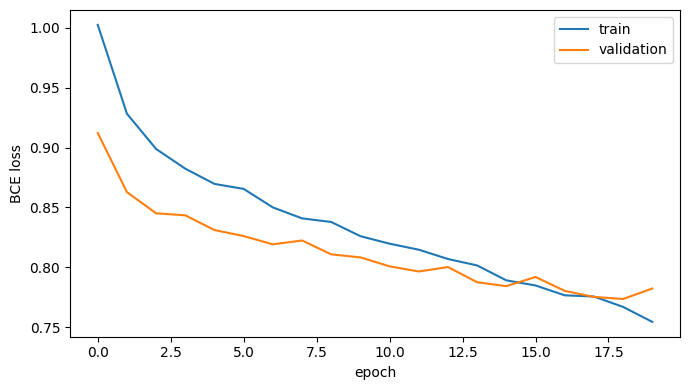

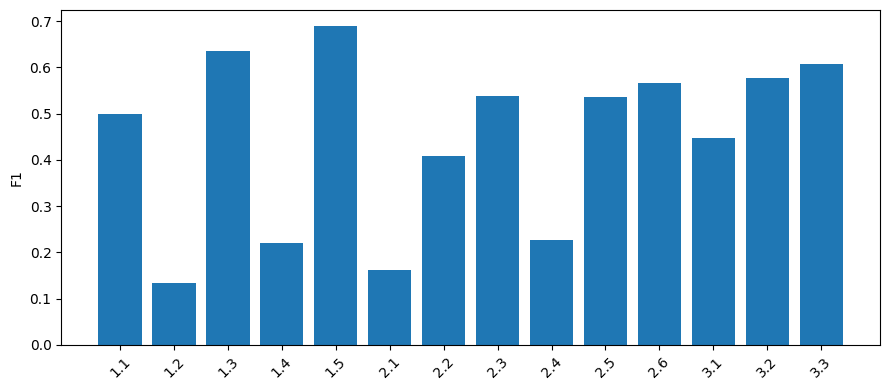

,trace_id,label_errors
0,ChatDev::8,11.0
1,Magentic::891,10.0
2,Magentic::852,10.0
3,Magentic::862,10.0
4,Magentic::829,10.0
5,Magentic::835,10.0
6,Magentic::794,10.0
7,Magentic::836,10.0
8,Magentic::792,10.0
9,Magentic::789,10.0


In [12]:
plt.figure(figsize=(7,4)); plt.plot(history["train_loss"], label="train"); plt.plot(history["val_loss"], label="validation"); plt.legend(); plt.ylabel("BCE loss"); plt.xlabel("epoch"); plt.tight_layout(); plt.savefig(Path(CONFIG["figures_dir"]) / "fig01_loss.png", dpi=180); plt.show()
per_label = f1_score(test_y, test_pred, average=None, zero_division=0)
plt.figure(figsize=(9,4)); plt.bar(label_codes, per_label); plt.xticks(rotation=45); plt.ylabel("F1"); plt.tight_layout(); plt.savefig(Path(CONFIG["figures_dir"]) / "fig02_failure_mode_f1.png", dpi=180); plt.show()
errors = np.abs(test_y - test_pred).sum(1)
worst = np.argsort(errors)[-10:][::-1]
display(pd.DataFrame({"trace_id": df.iloc[test_idx[worst]].trace_id.to_numpy(), "label_errors": errors[worst]}))